# Walmart Store-Level Time Series: Growth, Volatility, and Forecastability

Real weekly sales totals for 45 Walmart stores, Feb 2010 - Oct 2012.

**A note on the data:** this covers the same underlying stores and time period as the companion [walmart-recruiting-sales-analysis](https://github.com/PeterImoniose/walmart-recruiting-sales-analysis) repo - in fact the weekly totals match it almost exactly (e.g. both show £80,931,415.60 for the week of 24-26 Dec 2010). That repo has the department-level detail this one doesn't; this one is aggregated to one row per store per week, which is exactly the right shape for a genuinely different question: not *what* drives sales (already covered there), but **which stores behave predictably enough to forecast well, and which don't.**

Dataset link: https://www.kaggle.com/datasets/mikhail1681/walmart-sales

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.facecolor'] = 'white'
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Loading

One row per store per week - already clean (no missing values, no duplicates, no negative sales), so this goes straight into the actual analysis.

In [2]:
DATA_DIR = r'D:\files\Sales Datasets\Dataset6'

df = pd.read_csv(f'{DATA_DIR}\\Walmart_Sales.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(f'{len(df):,} store-weeks | {df["Store"].nunique()} stores')
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f'Missing values: {df.isnull().sum().sum()} | Duplicates: {df.duplicated().sum()} | Negative sales: {(df.Weekly_Sales < 0).sum()}')
df.head()

6,435 store-weeks | 45 stores
Date range: 2010-02-05 to 2012-10-26
Missing values: 0 | Duplicates: 0 | Negative sales: 0


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11


## 2. How much do stores differ in scale?

Before asking about predictability, it's worth seeing just how different these 45 stores are in absolute size - the spread turns out to be enormous.

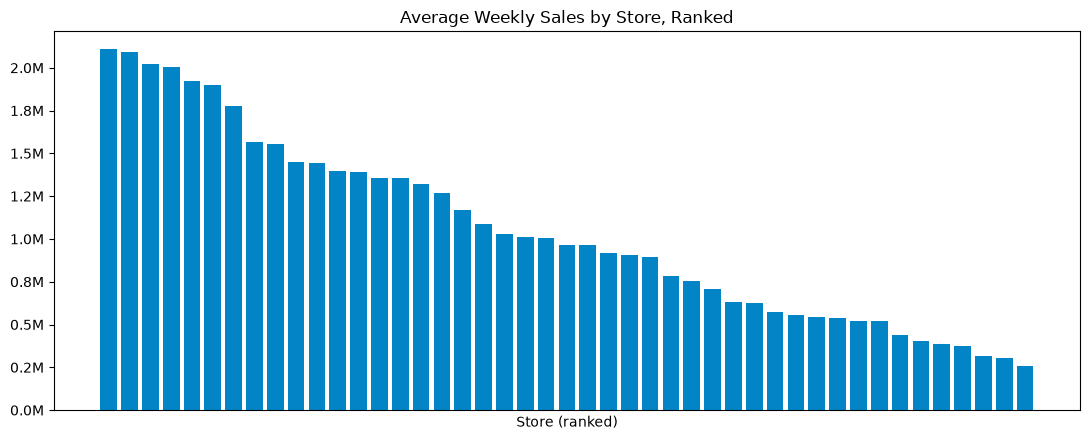

Top store: 2,107,677/week | Bottom store: 259,862/week - a 8.1x gap


In [3]:
store_avg = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(store_avg.index.astype(str), store_avg.values, color='#0284c7')
ax.set_title('Average Weekly Sales by Store, Ranked')
ax.set_xlabel('Store (ranked)')
ax.set_xticks([])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

print(f'Top store: {store_avg.iloc[0]:,.0f}/week | Bottom store: {store_avg.iloc[-1]:,.0f}/week '
      f'- a {store_avg.iloc[0] / store_avg.iloc[-1]:.1f}x gap')

## 3. Which stores are growing, and which are shrinking?

Comparing each store's average weekly sales in 2010 vs. 2011 (the only two full calendar years in the data).

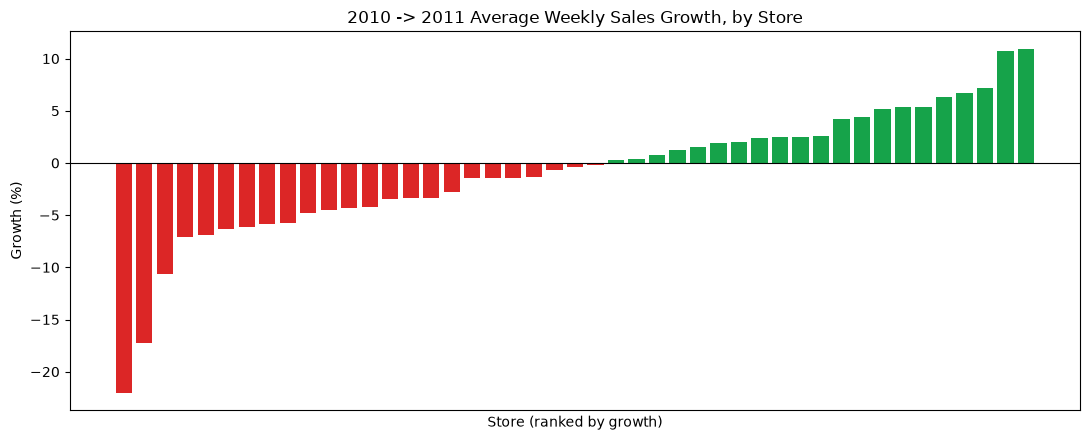

21/45 stores grew year over year
Best performer: Store 38 (+11.0%) | Worst: Store 35 (-22.0%)
Fleet-wide average change: -0.9% - essentially flat overall, masking real divergence at the individual store level.


In [4]:
df['Year'] = df['Date'].dt.year
yearly = df.groupby(['Store', 'Year'])['Weekly_Sales'].mean().unstack()
growth = (yearly[2011] - yearly[2010]) / yearly[2010]

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ['#16a34a' if g > 0 else '#dc2626' for g in growth.sort_values()]
ax.bar(range(len(growth)), growth.sort_values().values * 100, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('2010 -> 2011 Average Weekly Sales Growth, by Store')
ax.set_ylabel('Growth (%)')
ax.set_xlabel('Store (ranked by growth)')
ax.set_xticks([])
plt.tight_layout()
plt.show()

print(f'{(growth > 0).sum()}/{len(growth)} stores grew year over year')
print(f'Best performer: Store {growth.idxmax()} ({growth.max():+.1%}) | '
      f'Worst: Store {growth.idxmin()} ({growth.min():+.1%})')
print(f'Fleet-wide average change: {growth.mean():+.1%} - essentially flat overall, '
      f'masking real divergence at the individual store level.')

## 4. Which stores are the most (and least) predictable?

This is the core question for this notebook: forecasting a store with stable, consistent week-to-week sales is a very different problem from forecasting an erratic one. The coefficient of variation (std / mean) is a simple, scale-free way to measure that consistency per store.

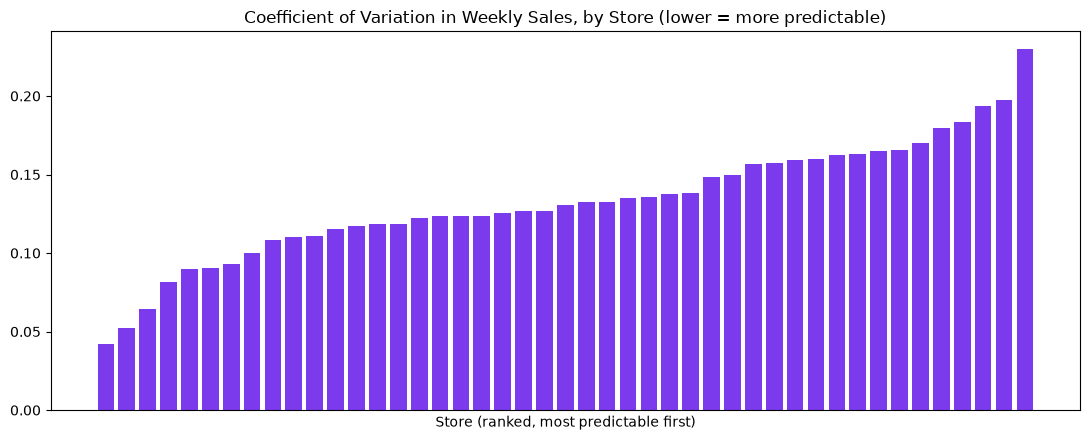

Most predictable: Store 37 (CV=0.042)
Most volatile: Store 35 (CV=0.230) - over 5x more variable, relative to its own scale
Fleet-wide CV: mean 0.133, ranging 0.042 to 0.230


In [5]:
store_stats = df.groupby('Store')['Weekly_Sales'].agg(['mean', 'std'])
store_stats['cv'] = store_stats['std'] / store_stats['mean']
store_stats = store_stats.sort_values('cv')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(store_stats.index.astype(str), store_stats['cv'], color='#7c3aed')
ax.set_title('Coefficient of Variation in Weekly Sales, by Store (lower = more predictable)')
ax.set_xlabel('Store (ranked, most predictable first)')
ax.set_xticks([])
plt.tight_layout()
plt.show()

most_stable = store_stats['cv'].idxmin()
most_volatile = store_stats['cv'].idxmax()
print(f"Most predictable: Store {most_stable} (CV={store_stats.loc[most_stable, 'cv']:.3f})")
print(f"Most volatile: Store {most_volatile} (CV={store_stats.loc[most_volatile, 'cv']:.3f}) - "
      f"over 5x more variable, relative to its own scale")
print(f"Fleet-wide CV: mean {store_stats['cv'].mean():.3f}, ranging {store_stats['cv'].min():.3f} to {store_stats['cv'].max():.3f}")

## 5. Is the seasonal pattern actually consistent year to year?

A high-value question for forecasting specifically: if this week's sales look similar to the same calendar week last year, a simple seasonal-naive model would already do well, without needing anything sophisticated.

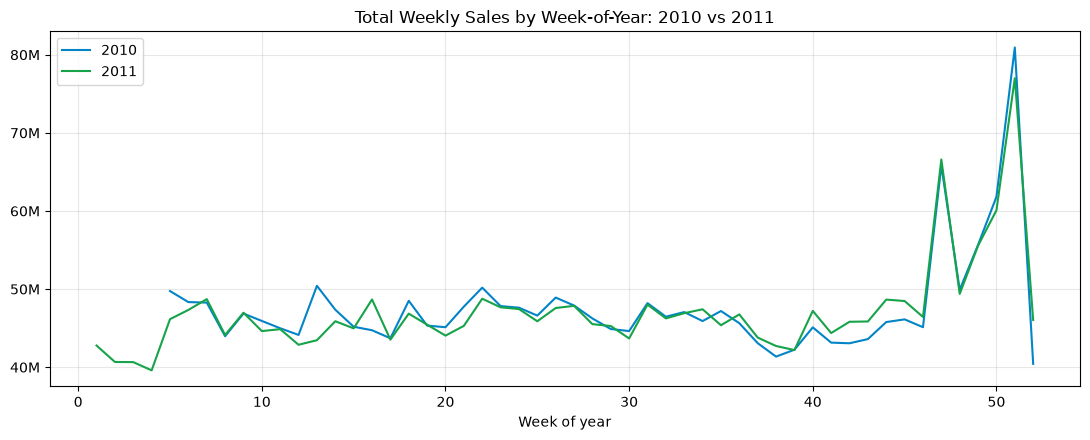

Correlation between the 2010 and 2011 week-of-year sales pattern: 0.953
A very strong match - the seasonal shape repeats reliably year to year, which is
exactly the condition under which a seasonal-naive baseline ("same week, last year")
is a strong, cheap starting point before reaching for anything more complex.


In [6]:
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
weekly_totals = df.groupby(['WeekOfYear', 'Year'])['Weekly_Sales'].sum().unstack()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(weekly_totals.index, weekly_totals[2010], label='2010', color='#0284c7')
ax.plot(weekly_totals.index, weekly_totals[2011], label='2011', color='#16a34a')
ax.set_title('Total Weekly Sales by Week-of-Year: 2010 vs 2011')
ax.set_xlabel('Week of year')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

seasonal_corr = weekly_totals[2010].corr(weekly_totals[2011])
print(f'Correlation between the 2010 and 2011 week-of-year sales pattern: {seasonal_corr:.3f}')
print('A very strong match - the seasonal shape repeats reliably year to year, which is')
print('exactly the condition under which a seasonal-naive baseline ("same week, last year")')
print('is a strong, cheap starting point before reaching for anything more complex.')

## 6. Holiday effect, at store-week level

A quick consistency check against the department-level finding in the companion Walmart Recruiting analysis.

In [7]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
uplift = holiday_sales[1] / holiday_sales[0] - 1
print(f'Holiday weeks average {holiday_sales[1]:,.0f} vs {holiday_sales[0]:,.0f} - a {uplift:+.1%} uplift')
print('Consistent with the +7.1% found at department level in the companion analysis -')
print('the aggregation level does not change the size of the holiday effect.')

Holiday weeks average 1,122,888 vs 1,041,256 - a +7.8% uplift
Consistent with the +7.1% found at department level in the companion analysis -
the aggregation level does not change the size of the holiday effect.


## Key findings

- **Store scale varies enormously**: an 8.1x gap between the top and bottom store's average weekly sales - any fleet-wide model needs to account for this rather than treating stores as interchangeable.
- **Fleet-wide growth was essentially flat (-0.9%) from 2010 to 2011, but that masks real divergence**: 21 of 45 stores grew, ranging from -22.0% to +11.0% individually - the fleet average hides meaningfully different store-level trajectories.
- **Predictability varies a lot between stores** (coefficient of variation ranging 0.042 to 0.230) - some stores have near-clockwork weekly sales, others are far more erratic, which matters directly for how much forecasting effort each store justifies.
- **The seasonal week-of-year pattern is highly consistent year to year** (r = 0.953 between 2010 and 2011) - strong evidence that a simple seasonal-naive baseline would already perform well here, which is valuable to know before building anything more complex.
- **The holiday-week sales uplift (+7.8%) matches the department-level finding (+7.1%) closely** - a useful consistency check confirming the effect isn't an artefact of aggregation level.

## Next steps

The natural follow-up is per-store forecasting, prioritised by what this notebook found: start with a seasonal-naive baseline given how strong the year-over-year seasonal correlation is, then focus modelling effort on the higher-CV (less predictable) stores identified in Section 4, where a naive baseline is least likely to be good enough on its own.